<h1><center>  Lab3 </center></h1>
<h1><center>  ECNM10115 Programming and Numerical Methods for Economics </center></h1>

#

#

#

###### <h1><center>  PS1: Feedback

#

#

#

#

### PS1: Feedback: General Comments 
*     From Lecture 1: Submission of the problem set must consist of a SINGLE DOCUMENT containing all the answers and the code for all the exercises.

*  __The document must be called: PSX groupY.__ 
*      Please make sure to avoid typos.

*      Submit only one file per submission.

*      Use Markdown syntax to improve the presentation of your work.

*      Include the relevant equations to describe your work.

*      Provide economic interpretations for your figures and results.

*      Add references if it is necessary. Please the university guidelines for using AI.

*  https://information-services.ed.ac.uk/computing/communication-and-collaboration/elm/generative-ai-guidance-for-students/using-generative


#

# 

### PS1: Feedback:  Statistics


 | Statistic | Value | 
 |:--------:|:--------:|
 | Mean | 69 | 
 | SD |6 |
 | Min| 55 |
 | Max | 79 |


*As a reference, last Year PS1 average was 62. 


#

# 

#

#

#

# Import Libraries, Functions and Display Settings

In [76]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(23)  # fix the seed at the beginning and only once.
import os
import quantecon as qe 
# os.chdir(r"C:\Users\jzurita\OneDrive - University of Edinburgh\Courses\Programming Numerical Methods\Week 4")

# from functions import  gini
# import quantecon as qe 
import warnings
warnings.filterwarnings('ignore')

 # 

## Exercise 1

### Tips

### $$y_i = 2 + 0.5x_{2,i} + e_{i}$$

#### Check: StatsModels Library

https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html

In [ ]:
# Library
import statsmodels.api as sm

Y = X0 + 0.5*X1 + ei

model= sm.OLS(Y,X)

results=model.fit()




### Simulations

# $$\begin{bmatrix}
t   & 1    & 2    & 3    & ... & T    \\ 
N=1 & y_1 & y_2 & y_3 & ... & y_T \\ 
\end{bmatrix} $$


## Exercise 2

## $$y_{t+1} = a + rho \times y_t + e_t$$
where 
                
##  $$e_t \sim N(0,\sigma_e)$$

#### Let's define a function for an AR(1) process

# What are the arguments of that function?

# $$\mathbf{F}\left(x,x,x,x,x \right)= OUTPUT $$

## What are the $x_s$?

###  We run a simulation of the AR(1) for t=T.

# $$\begin{bmatrix}
t   & 1    & 2    & 3    & ... & T    \\ 
N=1 & y_1 & y_2 & y_3 & ... & y_T \\ 
\end{bmatrix} $$


### We run two simulations of the AR(1) for t=T.

N=2 (Two simulations).... N=N (N simulations)
# $$\begin{bmatrix}
t   & 1    & 2    & 3    & ... & T    \\ 
N=1 & y_{1,1} & y_{1,2} & y_{1,3} & ... & y_{1,T} \\
N=2 & y_{2,1} & y_{2,2} & y_{2,3} & ... & y_{2,T} \\
... & ... & ... & ... & ... &... \\
N=N & y_{N,1} & y_{N,2} & y_{N,3} & ... & y_{N,T} \\
\end{bmatrix} $$


# $$\begin{bmatrix}
N \times T
\end{bmatrix} $$


### If we add an initial value at t=0 (y_0=0)

# $$\begin{bmatrix}
t   &0 & 1    & 2    & 3    & ... & T    \\ 
N=1 &y_0& y_{1,1} & y_{1,2} & y_{1,3} & ... & y_{1,T} \\
N=2 & y_0&y_{2,1} & y_{2,2} & y_{2,3} & ... & y_{2,T} \\
... &y_0& ... & ... & ... & ... &... \\
N=N & y_0&y_{N,1} & y_{N,2} & y_{N,3} & ... & y_{N,T} \\
\end{bmatrix} $$

# $$\begin{bmatrix}
N \times (T+1)
\end{bmatrix} $$



#

#

In [81]:
rho_a= 0.5
sigma_a=0.15

# a Simulate and plot the AR(1) process given by equation (1) for T=50 periods.

def ar_1_sim(T,rho,y0=0,a=0,sigma_e=1):
    '''
    ar_1_sim simulates for T periods an AR(1) process of the following form:
                y_t+1 = a + rho*y_t + e_t
                where e_t ~ N (0,sigma_e)
    '''
    y = np.empty(T+1) # store your elements - A vector Tx1
    y[0] = y0 # allocate my initial value in the first row
    for i in range(1,T+1):
        e = np.random.normal(0,sigma_e,1) 
        y[i] = a+ rho*y[i-1]+e
   
    return y

#### Let's create a graph

 
2a =======)


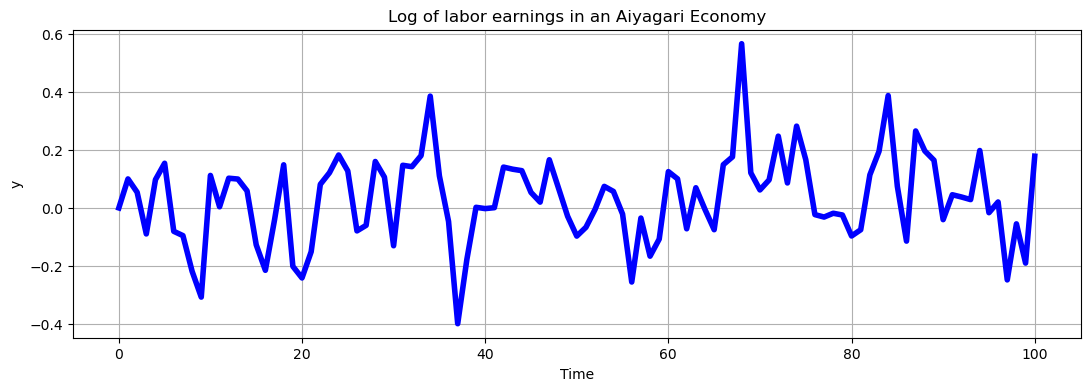

In [83]:
T=100

y1 = ar_1_sim(T,rho=rho_a, sigma_e=sigma_a)

print(' ')
print('2a =======)')
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(range(0,T+1), y1, linewidth=4.0, color='b')
ax.set_xlabel('Time')
ax.set_ylabel('y')
ax.set_title(r'Log of labor earnings in an Aiyagari Economy')
ax.grid()
plt.show()

<center>

### <center>How to simulate this process T times?  

## Steps:
1. ## Using our previous function, identify what objects will change?
2. ## Identify if we need new objects
3. ## Work line by line
     1. ### What's the size of my output now? $\implies$ allocation object should be different
     2. ### Do I need more arguments in my function?
     3. ### What is the size of $\epsilon$?
     4. ### If $\epsilon$ is size $=$  $r\times c$, this implies that y, in each iteration, must have the same dimentions.
     5. ### Think how to store the value of y in each iteration. 

In [99]:
def ar_1_sim_N(T,rho,y0=0,a=0,sigma_e=1):        
    ''' 
    ar_1_sim simulates for T periods an AR(1) process of the following form:
                y_t+1 = a + rho*y_t + e_t
                where e_t ~ N (0,sigma_e)
    '''
    y = np.empty(T+1) #(101,1)
    y[0] = y0
    for i in range(1,T+1):
        e = np.random.normal(0,sigma_e,1) # 1
        y[i] = a+ rho*y[i-1]+e #(101,1)
   
    return y   

In [101]:
T=100
N=1
output = ar_1_sim_N(T=T,rho=rho_a,sigma_e=sigma_a)

In [103]:
np.shape(output)

(101,)

In [ ]:
## b. AR(1) for size N,T

def ar_1_sim_N(N,T,rho,y0=0,a=0,sigma_e=1):
    y = np.empty((N,T+1))
    y[:,0] = y0
    
    for i in range(1,T+1):
        e = np.random.normal(0,sigma_e,N) 
        y[:,i] = a+ rho*y[:,i-1]+e
   
    return y


In [129]:
len(five_ar1s)

5

 
2c =======)


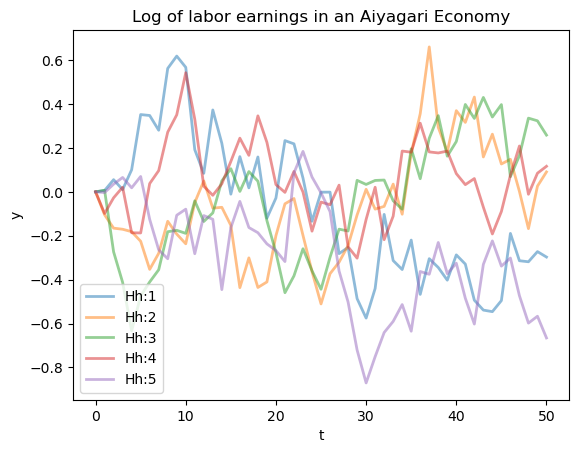

In [127]:
print(' ')
print('2c =======)')
fig, ax = plt.subplots()
for i in range(0,len(five_ar1s)):
    ax.plot(range(0,T+1), five_ar1s[i,:], linewidth=2.0, alpha=0.5, label='Hh:'+str(i+1))
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title(r'Log of labor earnings in an Aiyagari Economy')
ax.legend()
plt.show() 

#### 1. Discretizing AR(1) process into a Markov Chain

In [89]:
from quantecon import rouwenhorst

In [95]:
# 1. Let's have the 2 AR(1) we saw in this class:
y1 = ar_1_sim(10000,rho=0.25, a=0)
y2 = ar_1_sim(10000,rho=0.25,a=2)
mean_y1 = np.mean(y1)
mean_y2 = np.mean(y2)
print('mean of Ar(1) y1:', mean_y1) # approx mu* = a/(1-rho) = 0
print('mean of Ar(1) y2:', mean_y2)  # approx mu* = a/(1-rho) = 2/(1-0.25) =2.66

mean of Ar(1) y1: -0.028307597572529593
mean of Ar(1) y2: 2.6613404190150374


In [97]:
#rouwenhorst(n, rho, sigma, mu=0.0)
mc_ar1 = rouwenhorst(5,0.25,1, mu=0)
P1 = mc_ar1.P
psi1_star = mc_ar1.stationary_distributions
y1_values = mc_ar1.state_values

##### The expected value (mu*) of y1 is:

In [99]:
mean_mc_y1 =  psi1_star@y1_values   # note that matrix product is equivalent to sum(p_i*y_i)
print('mean of Ar(1) y1:', mean_y1)
print('mean MC approx of AR(1) y1:', mean_mc_y1)

mean of Ar(1) y1: -0.028307597572529593
mean MC approx of AR(1) y1: [0.]


In [101]:
mc_ar2 = rouwenhorst(5,0.25,1, mu=2)
P2 = mc_ar2.P
psi2_star = mc_ar2.stationary_distributions
y2_values = mc_ar2.state_values

In [103]:
mean_mc_y2 =  psi2_star@y2_values
print('mean of Ar(1) y2:', mean_y2)
print('mean MC approx of AR(1) y1:', mean_mc_y2)


mean of Ar(1) y2: 2.6613404190150374
mean MC approx of AR(1) y1: [2.66666667]
